<a href="https://colab.research.google.com/github/crossbone72/AI-Class/blob/main/weak5/diabetes_regression_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/diabetes.csv'

df = pd.read_csv(path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
df=df.drop('Outcome',axis=1)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [3]:
y=df['BMI']
y.value_counts()
y

,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1
...,...
763,32.9
764,36.8
765,26.2
766,30.1


In [4]:
X=df.drop('BMI',axis=1)
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33
...,...,...,...,...,...,...,...
763,10,101,76,48,180,0.171,63
764,2,122,70,27,0,0.340,27
765,5,121,72,23,112,0.245,30
766,1,126,60,0,0,0.349,47


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=0)

평균제곱근오차 49.41151592580262
평균제곱근오차 49.41151592580262
평균제곱근오차 49.41151592580262


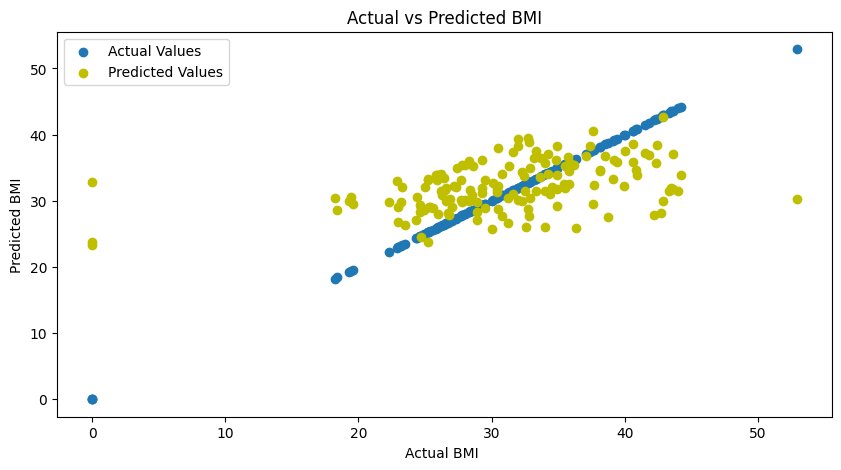

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(y_test, y_test, label='Actual Values')
plt.scatter(y_test, ly_preds, c='y', label='Predicted Values')
plt.xlabel('Actual BMI ')
plt.ylabel('Predicted BMI')
plt.title('Actual vs Predicted BMI')
plt.legend()
plt.show()

In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

model_dt = DecisionTreeRegressor(random_state=0)
model_dt.fit(X_train, y_train)

pred_dt = model_dt.predict(X_test)

print("--- Decision Tree Regressor ---")
print("평균제곱오차 (MSE):", mean_squared_error(y_test, pred_dt))

--- Decision Tree Regressor ---
평균제곱오차 (MSE): 92.02519480519481


In [8]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=0)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

print("--- Random Forest Regressor ---")
print("평균제곱오차 (MSE):", mean_squared_error(y_test, pred_rf))

--- Random Forest Regressor ---
평균제곱오차 (MSE): 48.024550831168874


In [9]:
#Y 원-핫 인코딩 실행
Y = pd.get_dummies(y).values

In [10]:
#딥러닝 모델 입력을 위해 X를 Numpy 배열로 변환
X = X.values

In [11]:
#전체 데이터를 학습용과 테스트용(8:2)으로 분리
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [12]:
#분할된 학습 및 테스트 데이터셋의 크기(shape) 확인
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((614, 7), (614, 248), (154, 7), (154, 248))

In [13]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

#3개의 은닉층을 가진 심층 신경망(DNN) 회귀 모델 설계
model = Sequential()

model.add(Dense(8,input_shape=(7,),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))

#모델 컴파일 설정 - 손실함수(mse)와 평가지표, 최적화 알고리즘(rmsprop)을 설정하여 학습 준비
model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

#모델 요약 정보 출력 - 생성된 신경망의 전체 구조, 층별 출력 형태, 학습 가능한 파라미터 수 확인
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295 (5.06 KB)

 Trainable params: 1,295 (5.06 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#모델 학습 실행 - 학습 데이터(train)를 이용해 최적의 가중치를 찾고, 테스트 데이터(test)로 매 에포크마다 성능 검증
N_EPOCHS = 10

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
#학습된 모델을 이용한 예측 - 테스트 데이터셋(X_test)을 입력하여 모델이 예측한 결과값을 산출
y_pred = model.predict(X_test)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.7945 - mse: 9.7945 - val_loss: 1.2910 - val_mse: 1.2910
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7916 - mse: 0.7916 - val_loss: 0.7197 - val_mse: 0.7197
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6270 - mse: 0.6270 - val_loss: 0.6121 - val_mse: 0.6121
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5671 - mse: 0.5671 - val_loss: 0.1724 - val_mse: 0.1724
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4351 - mse: 0.4351 - val_loss: 0.2369 - val_mse: 0.2369
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4518 - mse: 0.4518 - val_loss: 0.1442 - val_mse: 0.1442
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3585 - mse: 0.3585 - val_loss: 0.6281 - val_mse: 0.6281
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2950 - mse: 0.2950 - val_loss: 0.1020 - val_mse: 0.1020
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2983 - mse:

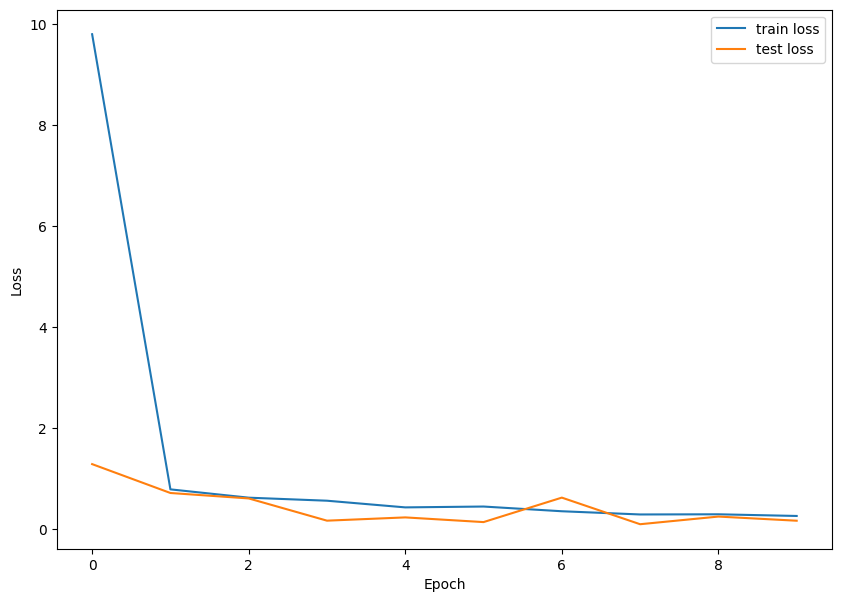

In [15]:
#학습 과정의 손실(loss) 변화 시각화 - 학습 데이터와 검증 데이터의 오차 추이 비교
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
#최종 모델 평가 - 테스트 데이터를 사용하여 모델의 손실(loss)과 평가지표 확인
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1712 - mse: 0.1712


[0.1712396740913391, 0.1712396740913391]